In [28]:
# Matrix Visualization Utilities for Complex Matrices
# ====================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Circle
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from qiskit.visualization import circuit_drawer

from qiskit.quantum_info import Operator, Statevector

def pretty_statevector(sv, tol=1e-6):
    n = int(np.log2(len(sv)))
    for i, amp in enumerate(sv):
        if abs(amp) > tol:
            b = format(i, f"0{n}b")
            print(f"|{b}> : {amp.real:+.4f}{amp.imag:+.4f}i  (|amp|={abs(amp):.4f})")
            
def show_action_on_basis(U):
    n = int(np.log2(U.shape[0]))
    print(f"Action on {n}-qubit basis:")
    for x in range(2**n):
        sv_out = Statevector(U @ Statevector.from_label(f"{x:0{n}b}").data)
        print(f"|{x:0{n}b}> → {sv_out}")

def show_action_on_basis_circuit(qc: QuantumCircuit):
    """Simulate qc on all computational basis inputs and print outputs."""
    n = qc.num_qubits
    # iterate over all 2^n basis states
    for x in range(2**n):
        # prepare basis state |x>
        b = format(x, f"0{n}b")
        sv_in = Statevector.from_label(b)
        # apply circuit
        sv_out = sv_in.evolve(qc)
        # print mapping
        print(f"|{b}> → {sv_out}")
        
def summarize_circuit(qc):
    print("Depth:", qc.depth())
    print("Size:", qc.size())
    print("Gate counts:", qc.count_ops())
    
def compare_actions(U1, U2):
    n = int(np.log2(len(U1)))
    print(f"Comparing two {n}-qubit unitaries:")
    for x in range(2**n):
        v = np.zeros(2**n)
        v[x] = 1
        out1 = U1 @ v
        out2 = U2 @ v
        print(f"|{x:0{n}b}>:")
        print(" U1 →", out1)
        print(" U2 →", out2)
        print("---")
        

def plot_statevector(sv, title="Statevector"):
    probs = np.abs(sv)**2
    phases = np.angle(sv)

    fig, ax1 = plt.subplots(figsize=(8,4))
    ax1.bar(range(len(sv)), probs)
    ax1.set_title(title + " – Probabilities")
    ax1.set_xlabel("Basis state index")
    ax1.set_ylabel("|amp|^2")
    plt.show()

    fig, ax2 = plt.subplots(figsize=(8,4))
    ax2.bar(range(len(sv)), phases)
    ax2.set_title(title + " – Phases")
    ax2.set_xlabel("Basis state index")
    ax2.set_ylabel("phase")
    plt.show()

def show_circuit_mpl(qc, scale=0.7, figsize=(8,4)):
    return circuit_drawer(
        qc, output="mpl", scale=scale, fold=-1, idle_wires=False
    )

def plot_unitary(U, title="Unitary"):
    """Plot magnitude and phase (arg) of a unitary."""
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    
    im0 = axs[0].imshow(np.abs(U), cmap="viridis")
    axs[0].set_title("Magnitude |U|")
    plt.colorbar(im0, ax=axs[0])

    im1 = axs[1].imshow(np.angle(U), cmap="twilight_shifted")
    axs[1].set_title("Phase arg(U)")
    plt.colorbar(im1, ax=axs[1])

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()
    
def plot_complex_matrix_interactive(M, normalize_cols=True, tol=1e-10,
                                   title="Complex Matrix", filename=None):
    """
    Interactive plotly visualization with hover tooltips showing exact values.
    """
    M = np.asarray(M, dtype=complex)
    
    if normalize_cols:
        norms = np.linalg.norm(M, axis=0, keepdims=True)
        norms[norms == 0] = 1.0
        M = M / norms
    
    magnitude = np.abs(M)
    phase = np.angle(M)
    
    # Create RGB from phase
    hue = (phase + np.pi) / (2 * np.pi)
    hsv = np.zeros((*M.shape, 3))
    hsv[:, :, 0] = hue
    hsv[:, :, 1] = 1.0
    hsv[:, :, 2] = magnitude / magnitude.max() if magnitude.max() > 0 else 1.0
    rgb = mcolors.hsv_to_rgb(hsv)
    
    # Convert to format plotly expects
    rgb_uint = (rgb * 255).astype(int)
    
    # Create hover text
    hover_text = []
    for i in range(M.shape[0]):
        row = []
        for j in range(M.shape[1]):
            real = M[i, j].real
            imag = M[i, j].imag
            mag = magnitude[i, j]
            ph = phase[i, j]
            text = f"({i},{j})<br>" \
                   f"Value: {real:.4f} + {imag:.4f}i<br>" \
                   f"Magnitude: {mag:.4f}<br>" \
                   f"Phase: {ph:.4f} rad ({np.degrees(ph):.1f}°)"
            row.append(text)
        hover_text.append(row)
    
    fig = go.Figure(data=go.Heatmap(
        z=magnitude,
        text=hover_text,
        hovertemplate='%{text}<extra></extra>',
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title="Magnitude", thickness=15, len=0.7)
    ))
    
    # Update layout for clean appearance
    fig.update_layout(
        title=dict(text=title, x=0.5, xanchor='center', font=dict(size=16)),
        xaxis=dict(title="Column", side='bottom'),
        yaxis=dict(title="Row", autorange='reversed'),
        width=700,
        height=650,
        plot_bgcolor='white',
    )
    
    # Save the figure as png
    if filename is not None:
        fig.write_image(f"{filename}.png", scale=2)
    
    return fig


def plot_complex_heatmaps(M, normalize_cols=True, tol=1e-10, 
                          title="Real vs Imaginary Parts"):
    """
    Plot two heatmaps (side-by-side) for the real and imaginary components of M.
      - Column normalization (L2) can be enabled with normalize_cols.
      - Zeros (|entry| < tol) are masked (not plotted).
      - Real heatmap: RdBu (red = positive real, blue = negative real).
      - Imag heatmap: RdBu_r (blue = positive imag, red = negative imag).
    """
    M = np.asarray(M, dtype=complex)

    # Optional column-wise L2 normalization on the complex matrix
    if normalize_cols:
        norms = np.linalg.norm(M, axis=0, keepdims=True)  # uses |.| on complex entries
        norms[norms == 0] = 1.0
        M = M / norms

    Re = M.real
    Im = M.imag

    # Masks: don't plot near-zeros
    mask_re = np.abs(Re) < tol
    mask_im = np.abs(Im) < tol

    # Symmetric color limits per panel (so color intensity encodes signed magnitude)
    vmax_re = np.max(np.abs(Re[~mask_re])) if np.any(~mask_re) else 1.0
    vmax_im = np.max(np.abs(Im[~mask_im])) if np.any(~mask_im) else 1.0

    fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

    # Real part: red = positive real, blue = negative real
    sns.heatmap(
        Re, ax=axes[0], mask=mask_re, cmap="RdBu", center=0.0,
        vmin=-vmax_re, vmax=vmax_re, cbar=True, square=True,
        linewidths=0.1, linecolor="gray"
    )
    axes[0].set_title("Real(M)  (red=+real, blue=−real)")
    axes[0].set_xlabel("Columns")
    axes[0].set_ylabel("Rows")

    # Imag part: blue = positive imag (use reversed colormap)
    sns.heatmap(
        Im, ax=axes[1], mask=mask_im, cmap="RdBu_r", center=0.0,
        vmin=-vmax_im, vmax=vmax_im, cbar=True, square=True,
        linewidths=0.1, linecolor="gray"
    )
    axes[1].set_title("Imag(M)  (blue=+imag, red=−imag)")
    axes[1].set_xlabel("Columns")
    axes[1].set_ylabel("Rows")

    fig.suptitle(title, y=1.02, fontsize=12)
    return fig, axes


In [3]:
from qiskit.circuit.library import RXXGate, RYYGate
def RXY(theta, q1, q2, qc):
    # exp(-i theta (XX+YY)/2) using RXX and RYY
    qc.append(RXXGate(theta), [q1, q2])
    qc.append(RYYGate(theta), [q1, q2])

In [22]:
import numpy as np
from qiskit.circuit import Gate, QuantumCircuit, AncillaQubit
from qiskit import QuantumRegister, AncillaRegister

from qiskit.circuit.library import RZGate, XXPlusYYGate, SGate, SdgGate, CXGate

from qiskit.synthesis import TwoQubitBasisDecomposer

class SqrtISWAPGate(Gate):
    """Custom √iSWAP gate, built on Qiskit's iSwapGate().power(1/2)."""

    def __init__(self):
        super().__init__(name="sqrtiSWAP_ec", num_qubits=2, params=[])

    def _define(self):
        qc = QuantumCircuit(2, name="sqrtiSWAP_ec")
        # qc.append(iSwapGate().power(0.5), [0, 1])
        qc.append(XXPlusYYGate(theta=-np.pi/2), [0, 1])
        self.definition = qc.to_gate()

    def inverse(self):
        # (√iSWAP)^-1 = (√iSWAP)† = (iSWAP)^(-1/2)
        inv = QuantumCircuit(2, name="sqrtiSWAPdg")
        # inv.append(iSwapGate().power(-0.5), [0, 1])
        inv.append(XXPlusYYGate(theta=np.pi/2), [0, 1])
        gate = SqrtISWAPGate()
        gate.definition = inv.to_gate()
        return gate
    
    def to_matrix(self):
        """Return the matrix representation of the √iSWAP gate."""
        return XXPlusYYGate(theta=-np.pi/2).to_matrix()

class SqrtISWAPdagGate(Gate):
    """Custom √iSWAP† gate, built on Qiskit's iSwapGate().power(-1/2)."""

    def __init__(self):
        super().__init__(name="sqrtiSWAPdg_ec", num_qubits=2, params=[])

    def _define(self):
        qc = QuantumCircuit(2, name="sqrtiSWAPdg_ec")
        # qc.append(iSwapGate().power(-0.5), [0, 1])
        qc.append(XXPlusYYGate(theta=np.pi/2), [0, 1])
        self.definition = qc.to_gate()

    def inverse(self):
        # (√iSWAP)†^-1 = √iSWAP
        return SqrtISWAPGate()
    
    def to_matrix(self):
        """Return the matrix representation of the √iSWAP† gate."""
        return XXPlusYYGate(theta=np.pi/2).to_matrix()


class ISWAPGate(Gate):
    def __init__(self):
        super().__init__(name="iSWAP_ec", num_qubits=2, params=[])
    
    def _define(self):
        qc = QuantumCircuit(2, name="iSWAP_ec")
        # apply sqrt iSWAP twice
        qc.append(SqrtISWAPGate(), [0, 1])
        qc.append(SqrtISWAPGate(), [0, 1])
        
        self.definition = qc.to_gate()
    
    def inverse(self):
        inv = QuantumCircuit(2, name="iSWAPdg_ec")
        # apply sqrt iSWAP† twice
        qc.append(SqrtISWAPdagGate(), [0, 1])
        qc.append(SqrtISWAPdagGate(), [0, 1])
        
        gate = ISWAPGate()
        gate.definition = inv.to_gate()
        return gate
    

class CZFromXYGate(Gate):
    """Two-qubit CZ implemented (conceptually) from XY / √iSWAP + Rz.

    For now, the definition is just the standard CZ.
    Replace the circuit in `_define()` with your derived √iSWAP+Rz sequence.
    """

    def __init__(self):
        super().__init__(name="cz_xy", num_qubits=3, params=[])

    def _define(self):
        qr = QuantumRegister(2, "q")
        ar = AncillaRegister(1, "a")  # No ancillas needed here
        
        qc = QuantumCircuit(ar, qr, name="cz_xy")

        # Example structure (you fill in angles / pattern):
        qc.append(SqrtISWAPGate(), [0, 1])
        qc.append(SqrtISWAPGate(), [0, 1])
        qc.append(SqrtISWAPGate(), [1, 2])
        qc.append(SqrtISWAPGate(), [1, 2])
        
        qc.append(SqrtISWAPGate().inverse(), [0, 1])
        qc.append(SqrtISWAPGate().inverse(), [0, 1])
        
        qc.append(SqrtISWAPGate(), [0, 2])
        qc.append(SqrtISWAPGate(), [0, 2])
        
        qc.append(SGate(), [2]),
        qc.append(SdgGate(), [0]),

        self.definition = qc
        # self._definition = qc.to_gate()

    def inverse(self):
        """CZ is Hermitian and self-inverse."""
        return CZFromXYGate()



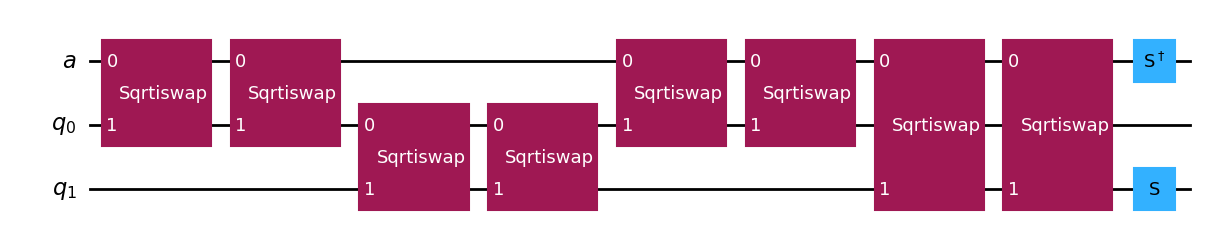

In [42]:
circ = QuantumCircuit(AncillaRegister(1, "ancilla"), QuantumRegister(2, "data"))
cz = CZFromXYGate()
circ.append(cz, [0, 1, 2])

# circ.draw("mpl")
cz.definition.draw("mpl")
# cz.definition.draw("mpl")
# get statevector \00> and apply cz
# sv = Statevector.from_label("011")
# sv_after = sv.evolve(circ)
# sv.draw("latex")
# sv_after.draw("latex")


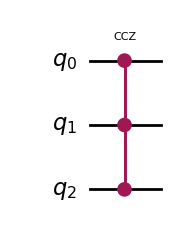

In [5]:
from qiskit.circuit.library import ZGate
ccz_gate = ZGate().control(2, label="CCZ")

qc_ccz = QuantumCircuit(3, name="CCZ_circuit")
qc_ccz.append(ccz_gate, [0, 1, 2])   # controls: q0, q1; target: q2

# Visualize
qc_ccz.draw("mpl")

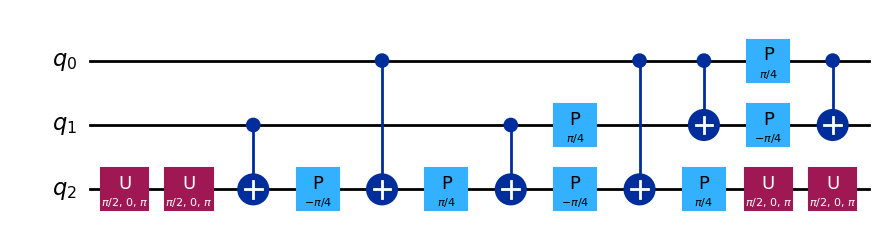

In [17]:
qc_decomp = qc_ccz.decompose(reps=3)
qc_decomp.draw("mpl")


# print(qc_decomp)

In [29]:
# Two-qubit basis decomposer with custom basis gate = SqrtISWAPGate
sqrt_iswap_basis = SqrtISWAPGate()
decomposer = TwoQubitBasisDecomposer(
    sqrt_iswap_basis,
    euler_basis="U3",   # single-qubit unitaries (you can later reduce them to Rz/SX/etc)
)

# Decompose a single CX gate into √iSWAP + 1q gates
cx_to_sqrtiswap = decomposer(CXGate())
# print(cx_to_sqrtiswap.definition)
cx_to_sqrtiswap.draw("mpl")
show_action_on_basis_circuit(cx_to_sqrtiswap)

|00> → Statevector([ 8.53553391e-01-3.16062462e-01j,
              7.80073852e-17-5.70025557e-16j,
             -3.87433246e-01-1.46446609e-01j,
             -1.56512008e-16+2.29174431e-16j],
            dims=(2, 2))
|01> → Statevector([-2.14107415e-17-2.50337668e-16j,
              3.16062462e-01+1.46446609e-01j,
              2.14107415e-17-2.59942382e-16j,
              8.53553391e-01-3.87433246e-01j],
            dims=(2, 2))
|10> → Statevector([ 3.87433246e-01-1.46446609e-01j,
             -4.80405679e-17-3.97190799e-16j,
              8.53553391e-01+3.16062462e-01j,
              8.78825647e-18-5.44864676e-16j],
            dims=(2, 2))
|11> → Statevector([-6.37711481e-17-3.74218207e-16j,
              8.53553391e-01+3.87433246e-01j,
              2.46721660e-17+6.01997152e-17j,
             -3.16062462e-01+1.46446609e-01j],
            dims=(2, 2))


/var/folders/qv/f4vv6vrd3qn96rx6p0mvm4dc0000gn/T/ipykernel_17537/3207379104.py:3: UserWarning: Only know how to decompose properly for a supercontrolled basis gate.
  decomposer = TwoQubitBasisDecomposer(


In [15]:
from qiskit import transpile
basis_gates = ["rz", "xxplusyy"]

qc_transpiled = transpile(
    qc_ccz,
    basis_gates=basis_gates,
    optimization_level=3,
)

qc_transpiled.draw("mpl")


ValueError: Providing non-standard gates (xxplusyy) through the ``basis_gates`` argument is not allowed. Use the ``target`` parameter instead. You can build a target instance using ``Target.from_configuration()`` and provide custom gate definitions with the ``custom_name_mapping`` argument.

In [30]:
from qiskit.synthesis import OneQubitEulerDecomposer
import numpy as np

# Create decomposer with your preferred basis
decomposer = OneQubitEulerDecomposer('ZYZ')  # or 'ZXZ', 'XYX', 'U3', etc.

# Decompose a unitary
U = np.array([[1, 1], [1, -1]]) / np.sqrt(2)  # Hadamard
theta, phi, lam, global_phase = decomposer.angles_and_phase(U)

print(f"θ={theta}, φ={phi}, λ={lam}, phase={global_phase}")

θ=1.5707963267948966, φ=0.0, λ=3.141592653589793, phase=1.5707963267948966
